# dual beam simulations for ALS 5.3.2.1
awojdyla@lbl.gov, April 2026

We want to compute the size of the beam and the fringe size for a dual beam zoneplate :

+ numerical aperture: 0.01NA
+ focal distance: 12mm
+ central stop: 95um
+ spot size: 110nm
+ spot separation: 10um
+ design photon energy: 700 eV

see: https://github.com/dream-beam/dream/blob/main/dbz/dbz.ipynb

The camera is an andor Ikon-M 634 with 13um/pixels and 1024 pixels 



In [2]:
import numpy as np
import matplotlib.pyplot as plt

def propTF(uin_V_m, L_m, lambda_m, z_m):
    M = uin_V_m.size        # number of samples (grid points)
    dx_m = L_m/M            # grid spacing
    k_1_m = 2*np.pi/lambda_m # wavenumber

    # Frequency coordinates
    fx_1_m = np.linspace(-1/(2*dx_m), 1/(2*dx_m) - (1/L_m), M)
    
    # Transfer function for Fresnel propagation
    H = np.exp(-1j * np.pi * lambda_m * z_m * (fx_1_m**2))
    H = np.fft.fftshift(H)

    # Fourier transform input field
    Uin_V_m = np.fft.fft(np.fft.fftshift(uin_V_m))

    # Multiply in Fourier space
    Uout_V_m = H * Uin_V_m

    # Inverse FFT → propagated field
    uout_V_m = np.fft.ifftshift(np.fft.ifft(Uout_V_m))
    return uout_V_m

def gaussian(x_px, mean_px, fwhm_px):
    '''
    GAUSSIAN Returns a 1D gaussian
    gaussian(x_px, mean_px, fwhm_px)
    :param x_px: numpy array
    :param mean_px: double
    :param fwhm_px: double
    :return: numpy array
    '''
    sigma_x = fwhm_px/(2*np.sqrt(2*np.log(2)));
    return np.exp(-((x_px-mean_px)/(np.sqrt(2)*sigma_x))**2)

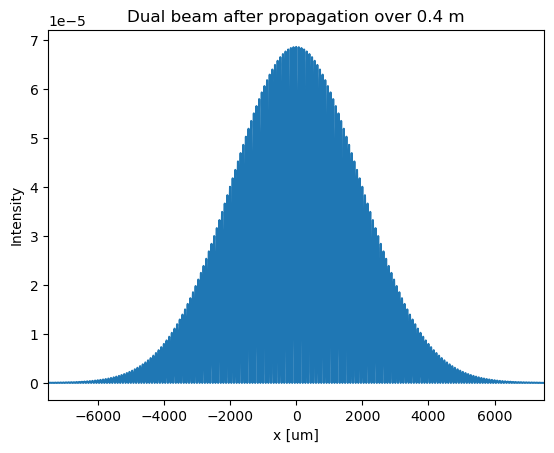

In [4]:
# grid size
dx_m= 10e-9
# screen size
Dx_m = 20e-3

# scale for x-axis
x_m = np.arange(-Dx_m/2, Dx_m/2, dx_m)

# generate two Gaussian beams
E1 = gaussian(x_m, -5e-6, 110e-9)
E2 = gaussian(x_m, +5e-6, 110e-9)
E= E1 + E2

z_m = 400e-3

ed = propTF(E, Dx_m, 2e-9, z_m)
plt.plot(x_m*1e6, np.abs(ed)**2)
plt.xlabel('x [um]')
plt.ylabel('Intensity')
plt.title('Dual beam after propagation over {} m'.format(z_m))
plt.xlim((-7500, 7500))
plt.show()

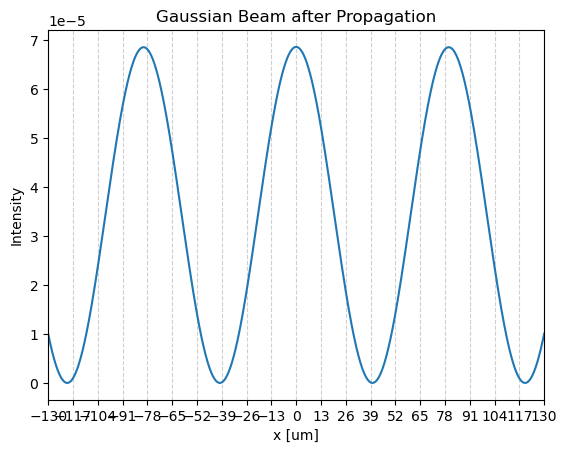

In [ ]:
plt.plot(x_m*1e6, np.abs(ed)**2)
plt.xlabel('x [um]')
plt.ylabel('Intensity')
plt.title('Dual beam after propagation over {} m'.format(z_m))
plt.xlim((-130, 130))

# vertical grid every 13 um
plt.xticks(np.arange(-130, 130 + 13, 13))
plt.grid(axis='x', which='major', linestyle='--', alpha=0.6)

plt.show()